# PPL

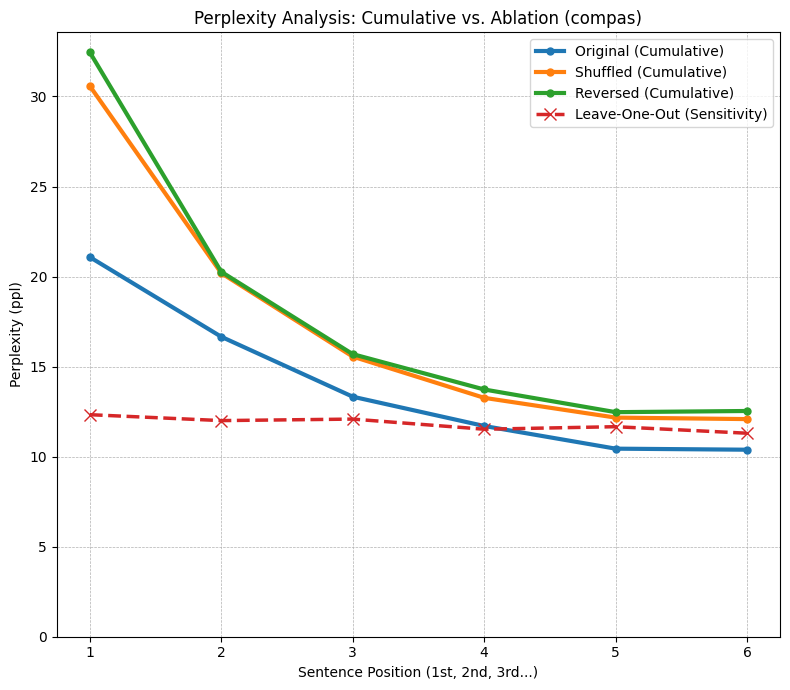

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os

path = "/home/mcedro/phd/repos/xain_xaid/XAIN_XAID/results/xaistories_narratives"
DATASET = "compas"

# --- 1) Load CSVs ---
ori_path  = os.path.join(path, DATASET, "ppl_cumulative.csv")
shuf_path = os.path.join(path, DATASET, "ppl_cumulative_shuffled.csv")
rev_path  = os.path.join(path, DATASET, "ppl_cumulative_rev.csv")
loo_path  = os.path.join(path, DATASET, "ppl_leave_one_out.csv")

df_ori  = pd.read_csv(ori_path)
df_shuf = pd.read_csv(shuf_path)
df_rev  = pd.read_csv(rev_path)
df_loo  = pd.read_csv(loo_path)

# --- 2) Normalize column names ---
df_shuf = df_shuf.rename(columns={"num_sentences_shuff": "num_sentences", "ppl_shuff": "ppl", "text_id_shuff": "text_id"})
df_rev = df_rev.rename(columns={"num_sentences_rev": "num_sentences", "ppl_rev": "ppl", "text_id_rev": "text_id"})

# --- 3) Compute Cumulative Means (The existing curves) ---
mean_ori  = df_ori.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_shuf = df_shuf.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_rev  = df_rev.groupby("num_sentences", as_index=False)["ppl"].mean()

# --- 4) Compute Leave-One-Out Curve ---
# Goal: Calculate mean PPL when sentence 0 is removed, when sentence 1 is removed, etc.
# This aligns with the x-axis (sentence index).
# Note: sentence_index 0 in LOO corresponds to num_sentences 1 in cumulative (1st item).
mean_loo = df_loo.groupby("sentence_index", as_index=False)["ppl_without_sentence"].mean()

# Shift LOO x-axis by +1 to align visually with "num_sentences" 
# (i.e., removing the 1st sentence (index 0) is plotted at x=1)
mean_loo["plot_index"] = mean_loo["sentence_index"] + 1

# --- 5) Plot ---
plt.figure(figsize=(8, 7))
ax = plt.gca()

# A. Cumulative Curves (Original, Shuffled, Reversed)
plt.plot(mean_ori["num_sentences"],  mean_ori["ppl"],  linewidth=3.0, marker='o', markersize=5, color="tab:blue",   label="Original (Cumulative)", zorder=5)
plt.plot(mean_shuf["num_sentences"], mean_shuf["ppl"], linewidth=3.0, marker='o', markersize=5, color="tab:orange", label="Shuffled (Cumulative)", zorder=5)
plt.plot(mean_rev["num_sentences"],  mean_rev["ppl"],  linewidth=3.0, marker='o', markersize=5, color="tab:green",  label="Reversed (Cumulative)", zorder=5)

# B. Leave-One-Out Curve (Sensitivity Profile)
# This curve shows: "What is the PPL if the sentence at this position is REMOVED?"
plt.plot(mean_loo["plot_index"], mean_loo["ppl_without_sentence"], 
         linewidth=2.5, color="tab:red", linestyle="--", marker='x', markersize=8, 
         label="Leave-One-Out (Sensitivity)", zorder=6)

# --- Formatting ---
plt.ylim(bottom=0)
# Ensure x-axis ticks are integers only
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title(f"Perplexity Analysis: Cumulative vs. Ablation ({DATASET})")
plt.xlabel("Sentence Position (1st, 2nd, 3rd...)")
plt.ylabel("Perplexity (ppl)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

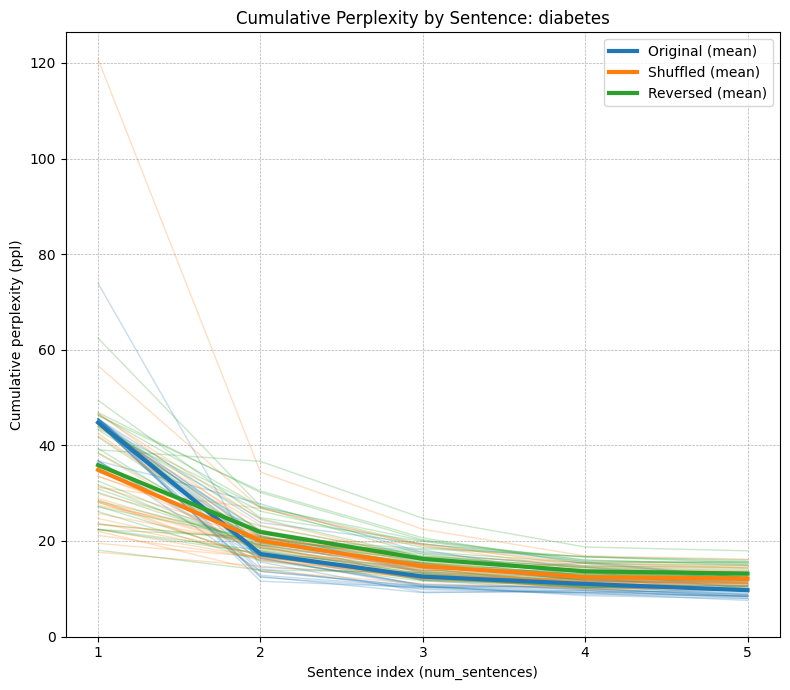

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os

path = "/home/mcedro/phd/repos/xain_xaid/XAIN_XAID/results/xaistories_narratives"
DATASET = "diabetes"

# --- 1) Load CSVs (update paths) ---
ori_path  = os.path.join(path, DATASET, "ppl_cumulative.csv")
shuf_path = os.path.join(path, DATASET, "ppl_cumulative_shuffled.csv")
rev_path  = os.path.join(path, DATASET, "ppl_cumulative_rev.csv")

df_ori  = pd.read_csv(ori_path)
df_shuf = pd.read_csv(shuf_path)
df_rev  = pd.read_csv(rev_path)

# --- 2) Normalize column names so we can reuse code ---
df_shuf = df_shuf.rename(columns={
    "text_id_shuff": "text_id",
    "num_sentences_shuff": "num_sentences",
    "last_sentence_shuff": "last_sentence",
    "ppl_shuff": "ppl"
})
df_rev = df_rev.rename(columns={
    "text_id_rev": "text_id",
    "num_sentences_rev": "num_sentences",
    "last_sentence_rev": "last_sentence",
    "ppl_rev": "ppl"
})

# --- 3) Sort within each series ---
df_ori  = df_ori.sort_values(["text_id", "num_sentences"])
df_shuf = df_shuf.sort_values(["text_id", "num_sentences"])
df_rev  = df_rev.sort_values(["text_id", "num_sentences"])

# --- 4) Compute mean curves (averaging across text_ids per sentence index) ---
mean_ori  = df_ori.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_shuf = df_shuf.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_rev  = df_rev.groupby("num_sentences", as_index=False)["ppl"].mean()

# --- 5) Plot ---
plt.figure(figsize=(8, 7))
ax = plt.gca()  # get current axes

# Faint per-sequence lines
for tid, g in df_ori.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:blue")
for tid, g in df_shuf.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:orange")
for tid, g in df_rev.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:green")

# Strong mean lines
plt.plot(mean_ori["num_sentences"],  mean_ori["ppl"],  linewidth=3.0, alpha=1.0, color="tab:blue",   label="Original (mean)", zorder=5)
plt.plot(mean_shuf["num_sentences"], mean_shuf["ppl"], linewidth=3.0, alpha=1.0, color="tab:orange", label="Shuffled (mean)", zorder=5)
plt.plot(mean_rev["num_sentences"],  mean_rev["ppl"],  linewidth=3.0, alpha=1.0, color="tab:green",  label="Reversed (mean)", zorder=5)

# >>> Make y start at 0 and x ticks integers <<<
plt.ylim(bottom=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title(f"Cumulative Perplexity by Sentence: {DATASET}")
plt.xlabel("Sentence index (num_sentences)")
plt.ylabel("Cumulative perplexity (ppl)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


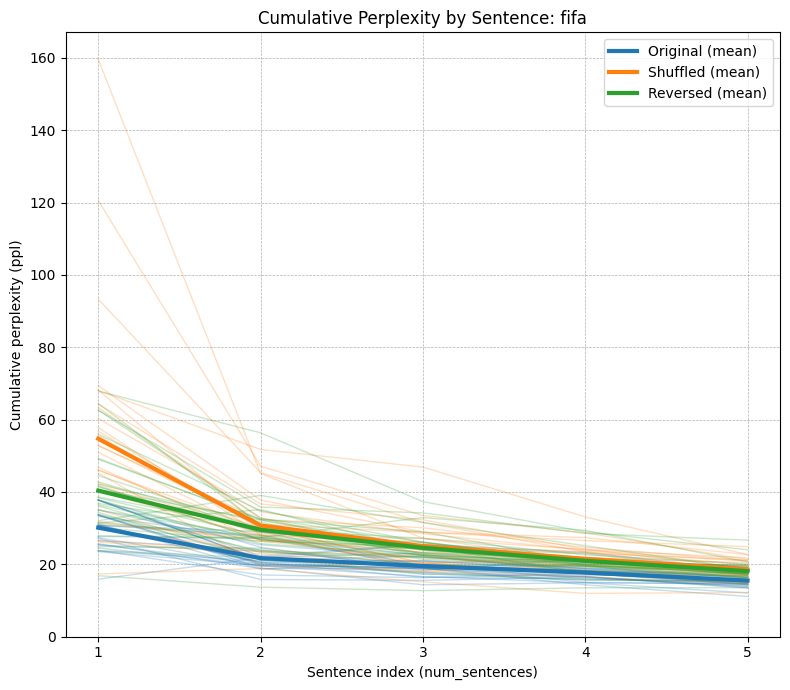

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os

path = "/home/mateuszcedro/mateuszcedro/PhD/repos/xain_xaid/results/xaistories"
DATASET = "fifa"

# --- 1) Load CSVs (update paths) ---
ori_path  = os.path.join(path, DATASET, "ppl_cumulative.csv")
shuf_path = os.path.join(path, DATASET, "ppl_cumulative_shuffled.csv")
rev_path  = os.path.join(path, DATASET, "ppl_cumulative_rev.csv")

df_ori  = pd.read_csv(ori_path)
df_shuf = pd.read_csv(shuf_path)
df_rev  = pd.read_csv(rev_path)

# --- 2) Normalize column names so we can reuse code ---
df_shuf = df_shuf.rename(columns={
    "text_id_shuff": "text_id",
    "num_sentences_shuff": "num_sentences",
    "last_sentence_shuff": "last_sentence",
    "ppl_shuff": "ppl"
})
df_rev = df_rev.rename(columns={
    "text_id_rev": "text_id",
    "num_sentences_rev": "num_sentences",
    "last_sentence_rev": "last_sentence",
    "ppl_rev": "ppl"
})

# --- 3) Sort within each series ---
df_ori  = df_ori.sort_values(["text_id", "num_sentences"])
df_shuf = df_shuf.sort_values(["text_id", "num_sentences"])
df_rev  = df_rev.sort_values(["text_id", "num_sentences"])

# --- 4) Compute mean curves (averaging across text_ids per sentence index) ---
mean_ori  = df_ori.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_shuf = df_shuf.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_rev  = df_rev.groupby("num_sentences", as_index=False)["ppl"].mean()

# --- 5) Plot ---
plt.figure(figsize=(8, 7))
ax = plt.gca()  # get current axes

# Faint per-sequence lines
for tid, g in df_ori.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:blue")
for tid, g in df_shuf.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:orange")
for tid, g in df_rev.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:green")

# Strong mean lines
plt.plot(mean_ori["num_sentences"],  mean_ori["ppl"],  linewidth=3.0, alpha=1.0, color="tab:blue",   label="Original (mean)", zorder=5)
plt.plot(mean_shuf["num_sentences"], mean_shuf["ppl"], linewidth=3.0, alpha=1.0, color="tab:orange", label="Shuffled (mean)", zorder=5)
plt.plot(mean_rev["num_sentences"],  mean_rev["ppl"],  linewidth=3.0, alpha=1.0, color="tab:green",  label="Reversed (mean)", zorder=5)

# >>> Make y start at 0 and x ticks integers <<<
plt.ylim(bottom=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title(f"Cumulative Perplexity by Sentence: {DATASET}")
plt.xlabel("Sentence index (num_sentences)")
plt.ylabel("Cumulative perplexity (ppl)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


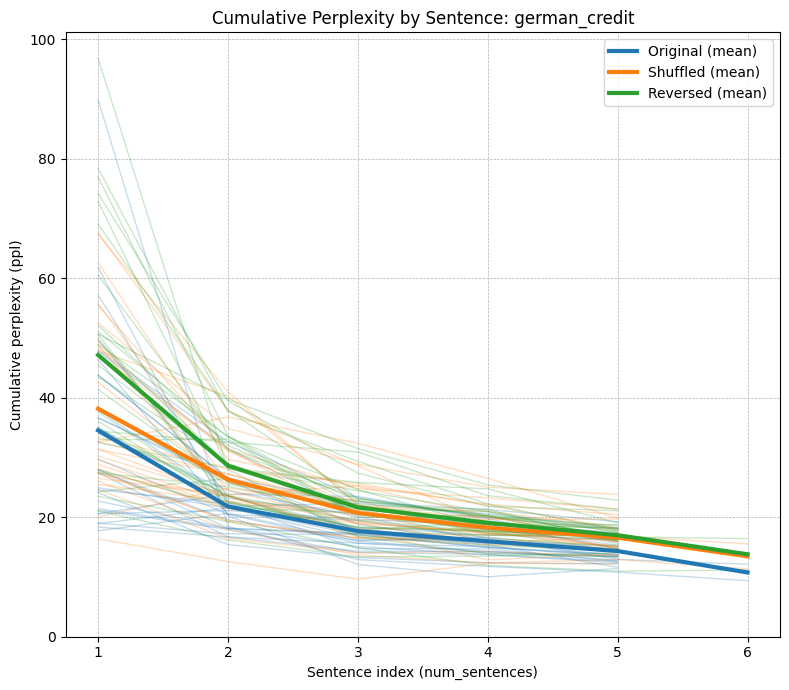

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os

path = "/home/mateuszcedro/mateuszcedro/PhD/repos/xain_xaid/results/xaistories"
DATASET = "german_credit"

# --- 1) Load CSVs (update paths) ---
ori_path  = os.path.join(path, DATASET, "ppl_cumulative.csv")
shuf_path = os.path.join(path, DATASET, "ppl_cumulative_shuffled.csv")
rev_path  = os.path.join(path, DATASET, "ppl_cumulative_rev.csv")

df_ori  = pd.read_csv(ori_path)
df_shuf = pd.read_csv(shuf_path)
df_rev  = pd.read_csv(rev_path)

# --- 2) Normalize column names so we can reuse code ---
df_shuf = df_shuf.rename(columns={
    "text_id_shuff": "text_id",
    "num_sentences_shuff": "num_sentences",
    "last_sentence_shuff": "last_sentence",
    "ppl_shuff": "ppl"
})
df_rev = df_rev.rename(columns={
    "text_id_rev": "text_id",
    "num_sentences_rev": "num_sentences",
    "last_sentence_rev": "last_sentence",
    "ppl_rev": "ppl"
})

# --- 3) Sort within each series ---
df_ori  = df_ori.sort_values(["text_id", "num_sentences"])
df_shuf = df_shuf.sort_values(["text_id", "num_sentences"])
df_rev  = df_rev.sort_values(["text_id", "num_sentences"])

# --- 4) Compute mean curves (averaging across text_ids per sentence index) ---
mean_ori  = df_ori.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_shuf = df_shuf.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_rev  = df_rev.groupby("num_sentences", as_index=False)["ppl"].mean()

# --- 5) Plot ---
plt.figure(figsize=(8, 7))
ax = plt.gca()  # get current axes

# Faint per-sequence lines
for tid, g in df_ori.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:blue")
for tid, g in df_shuf.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:orange")
for tid, g in df_rev.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:green")

# Strong mean lines
plt.plot(mean_ori["num_sentences"],  mean_ori["ppl"],  linewidth=3.0, alpha=1.0, color="tab:blue",   label="Original (mean)", zorder=5)
plt.plot(mean_shuf["num_sentences"], mean_shuf["ppl"], linewidth=3.0, alpha=1.0, color="tab:orange", label="Shuffled (mean)", zorder=5)
plt.plot(mean_rev["num_sentences"],  mean_rev["ppl"],  linewidth=3.0, alpha=1.0, color="tab:green",  label="Reversed (mean)", zorder=5)

# >>> Make y start at 0 and x ticks integers <<<
plt.ylim(bottom=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title(f"Cumulative Perplexity by Sentence: {DATASET}")
plt.xlabel("Sentence index (num_sentences)")
plt.ylabel("Cumulative perplexity (ppl)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


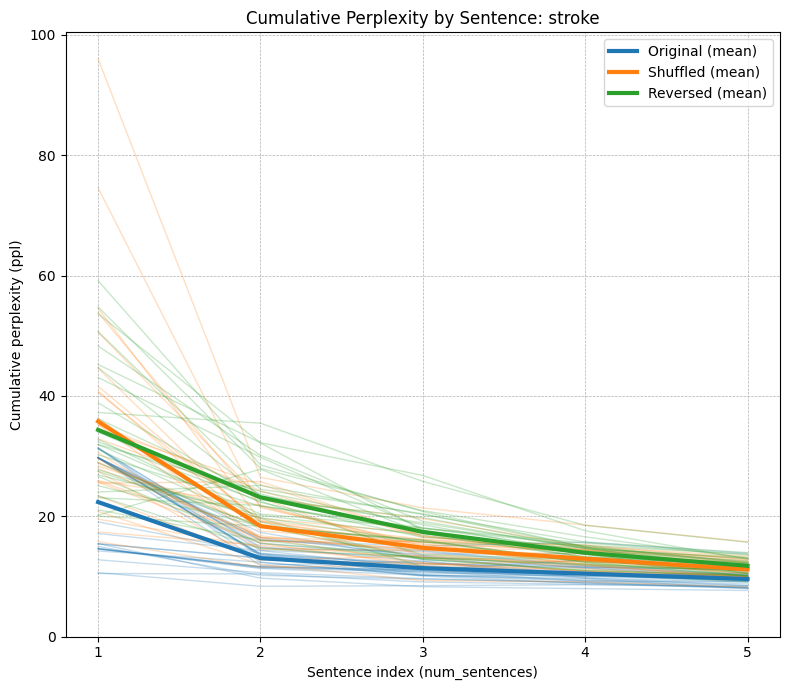

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os

path = "/home/mateuszcedro/mateuszcedro/PhD/repos/xain_xaid/results/xaistories"
DATASET = "stroke"

# --- 1) Load CSVs (update paths) ---
ori_path  = os.path.join(path, DATASET, "ppl_cumulative.csv")
shuf_path = os.path.join(path, DATASET, "ppl_cumulative_shuffled.csv")
rev_path  = os.path.join(path, DATASET, "ppl_cumulative_rev.csv")

df_ori  = pd.read_csv(ori_path)
df_shuf = pd.read_csv(shuf_path)
df_rev  = pd.read_csv(rev_path)

# --- 2) Normalize column names so we can reuse code ---
df_shuf = df_shuf.rename(columns={
    "text_id_shuff": "text_id",
    "num_sentences_shuff": "num_sentences",
    "last_sentence_shuff": "last_sentence",
    "ppl_shuff": "ppl"
})
df_rev = df_rev.rename(columns={
    "text_id_rev": "text_id",
    "num_sentences_rev": "num_sentences",
    "last_sentence_rev": "last_sentence",
    "ppl_rev": "ppl"
})

# --- 3) Sort within each series ---
df_ori  = df_ori.sort_values(["text_id", "num_sentences"])
df_shuf = df_shuf.sort_values(["text_id", "num_sentences"])
df_rev  = df_rev.sort_values(["text_id", "num_sentences"])

# --- 4) Compute mean curves (averaging across text_ids per sentence index) ---
mean_ori  = df_ori.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_shuf = df_shuf.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_rev  = df_rev.groupby("num_sentences", as_index=False)["ppl"].mean()

# --- 5) Plot ---
plt.figure(figsize=(8, 7))
ax = plt.gca()  # get current axes

# Faint per-sequence lines
for tid, g in df_ori.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:blue")
for tid, g in df_shuf.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:orange")
for tid, g in df_rev.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:green")

# Strong mean lines
plt.plot(mean_ori["num_sentences"],  mean_ori["ppl"],  linewidth=3.0, alpha=1.0, color="tab:blue",   label="Original (mean)", zorder=5)
plt.plot(mean_shuf["num_sentences"], mean_shuf["ppl"], linewidth=3.0, alpha=1.0, color="tab:orange", label="Shuffled (mean)", zorder=5)
plt.plot(mean_rev["num_sentences"],  mean_rev["ppl"],  linewidth=3.0, alpha=1.0, color="tab:green",  label="Reversed (mean)", zorder=5)

# >>> Make y start at 0 and x ticks integers <<<
plt.ylim(bottom=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title(f"Cumulative Perplexity by Sentence: {DATASET}")
plt.xlabel("Sentence index (num_sentences)")
plt.ylabel("Cumulative perplexity (ppl)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


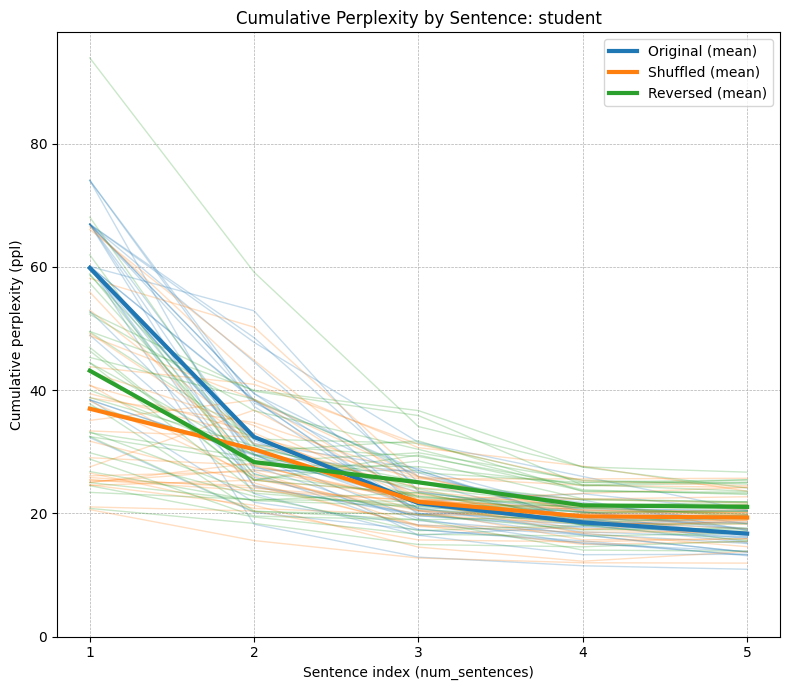

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import os

path = "/home/mateuszcedro/mateuszcedro/PhD/repos/xain_xaid/results/xaistories"
DATASET = "student"

# --- 1) Load CSVs (update paths) ---
ori_path  = os.path.join(path, DATASET, "ppl_cumulative.csv")
shuf_path = os.path.join(path, DATASET, "ppl_cumulative_shuffled.csv")
rev_path  = os.path.join(path, DATASET, "ppl_cumulative_rev.csv")

df_ori  = pd.read_csv(ori_path)
df_shuf = pd.read_csv(shuf_path)
df_rev  = pd.read_csv(rev_path)

# --- 2) Normalize column names so we can reuse code ---
df_shuf = df_shuf.rename(columns={
    "text_id_shuff": "text_id",
    "num_sentences_shuff": "num_sentences",
    "last_sentence_shuff": "last_sentence",
    "ppl_shuff": "ppl"
})
df_rev = df_rev.rename(columns={
    "text_id_rev": "text_id",
    "num_sentences_rev": "num_sentences",
    "last_sentence_rev": "last_sentence",
    "ppl_rev": "ppl"
})

# --- 3) Sort within each series ---
df_ori  = df_ori.sort_values(["text_id", "num_sentences"])
df_shuf = df_shuf.sort_values(["text_id", "num_sentences"])
df_rev  = df_rev.sort_values(["text_id", "num_sentences"])

# --- 4) Compute mean curves (averaging across text_ids per sentence index) ---
mean_ori  = df_ori.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_shuf = df_shuf.groupby("num_sentences", as_index=False)["ppl"].mean()
mean_rev  = df_rev.groupby("num_sentences", as_index=False)["ppl"].mean()

# --- 5) Plot ---
plt.figure(figsize=(8, 7))
ax = plt.gca()  # get current axes

# Faint per-sequence lines
for tid, g in df_ori.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:blue")
for tid, g in df_shuf.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:orange")
for tid, g in df_rev.groupby("text_id"):
    plt.plot(g["num_sentences"], g["ppl"], linewidth=1.0, alpha=0.25, color="tab:green")

# Strong mean lines
plt.plot(mean_ori["num_sentences"],  mean_ori["ppl"],  linewidth=3.0, alpha=1.0, color="tab:blue",   label="Original (mean)", zorder=5)
plt.plot(mean_shuf["num_sentences"], mean_shuf["ppl"], linewidth=3.0, alpha=1.0, color="tab:orange", label="Shuffled (mean)", zorder=5)
plt.plot(mean_rev["num_sentences"],  mean_rev["ppl"],  linewidth=3.0, alpha=1.0, color="tab:green",  label="Reversed (mean)", zorder=5)

# >>> Make y start at 0 and x ticks integers <<<
plt.ylim(bottom=0)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title(f"Cumulative Perplexity by Sentence: {DATASET}")
plt.xlabel("Sentence index (num_sentences)")
plt.ylabel("Cumulative perplexity (ppl)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# Cobined

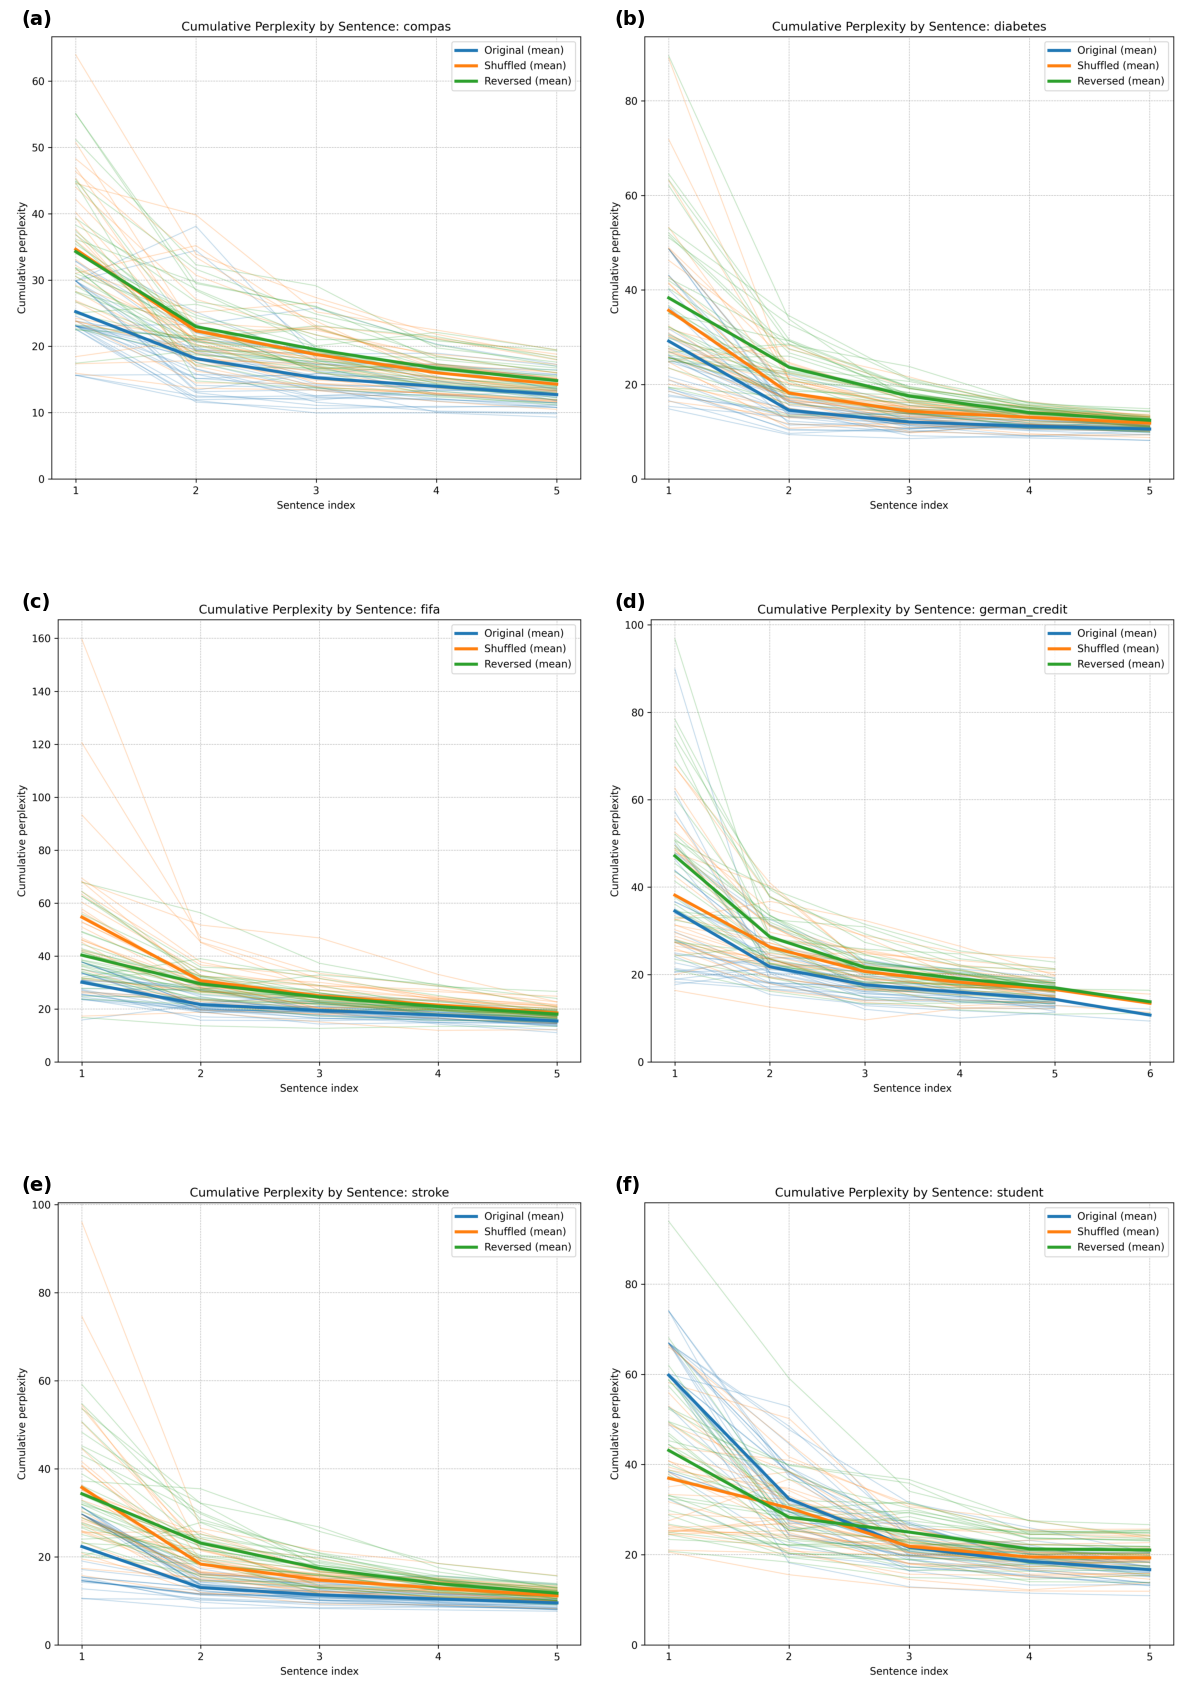

Combined chart saved as combined_charts32.png and combined_charts32.pdf


In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# List your 6 chart files
path = '/home/mateuszcedro/mateuszcedro/PhD/repos/xain_xaid/summary/plots/'

chart_files = [
    os.path.join(path,'cumulative_ppl_compas.png'),
    os.path.join(path,'cumulative_ppl_diabetes.png'),
    os.path.join(path,'cumulative_ppl_fifa.png'),
    os.path.join(path,'cumulative_ppl_german_credit.png'),
    os.path.join(path,'cumulative_ppl_stroke.png'),
    os.path.join(path,'cumulative_ppl_student.png')
]

# Create a 2x3 grid (3x2 now)
fig, axes = plt.subplots(3, 2, figsize=(12, 18)) # (18, 12) when 2x3
# fig.suptitle('Combined Charts', fontsize=20, y=0.98)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Load and display each chart
for idx, (ax, chart_file) in enumerate(zip(axes, chart_files)):
    if os.path.exists(chart_file):
        img = mpimg.imread(chart_file)
        ax.imshow(img)
        ax.axis('off')
        # Optional: Add subplot labels (a), (b), (c), etc.
        ax.text(0.02, 1.01, f'({chr(97+idx)})', transform=ax.transAxes,
                fontsize=14, fontweight='bold', va='top',
                #bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
                )
    else:
        ax.text(0.5, 0.5, f'Chart {idx+1}\nnot found', 
                ha='center', va='center', fontsize=12)
        ax.axis('off')

plt.tight_layout()
plt.savefig('summary/plots/combined_charts32.png', dpi=300, bbox_inches='tight')
plt.savefig('summary/plots/combined_charts32.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Combined chart saved as combined_charts32.png and combined_charts32.pdf")